# TD · Prétraitement des données · du papier au code

**ELC2 · Introduction au machine learning**

Ce notebook accompagne le TD *Prétraitement des données, atelier pratique* (le PDF du même
nom). Il suit le TD dans le même ordre :

1. le fichier `Data.csv` et ses problèmes ;
2. les cinq problèmes, un par un : **chaque calcul fait au crayon dans le TD est refait ici par
   Python**, pour vérifier ;
3. l'ordre des étapes, et le piège du *data leakage* ;
4. du papier au code : tout le prétraitement, appliqué au fichier complet.

Sur GitHub, le notebook s'affiche **avec ses résultats** : il se lit comme un corrigé guidé.
Dans Jupyter, exécutez les cellules dans l'ordre avec **Maj + Entrée**, ou d'un coup avec
**Run → Run All Cells**.

Le même traitement existe en script, sans les explications : `td-pretraitement.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Notre dataset : `Data.csv`

Chaque ligne est un client. Les colonnes :

| Colonne | Contenu |
|---|---|
| `Country` | le pays du client |
| `Age` | son âge |
| `Salary` | son salaire annuel |
| `Education` | son diplôme le plus élevé |
| `Experience` | ses années d'expérience professionnelle |
| `Purchased` | a-t-il acheté le produit ? (`Yes` ou `No`) : c'est la **cible**, ce qu'on voudra prédire |

In [2]:
data = pd.read_csv("donnees/Data.csv")
data.head(10)

,Country,Age,Salary,Education,Experience,Purchased
0,France,44.0,72000.0,Master,16,No
1,Spain,27.0,48000.0,Bachelor,5,Yes
2,Germany,30.0,54000.0,Bachelor,8,No
3,Spain,38.0,61000.0,Master,12,No
4,Germany,40.0,NaN,PhD,10,Yes
5,France,35.0,58000.0,Bachelor,13,Yes
6,Spain,NaN,52000.0,Bachelor,7,No
7,France,48.0,79000.0,Master,22,Yes
8,Germany,50.0,83000.0,PhD,20,No
9,France,37.0,67000.0,Master,11,Yes


Ce sont les 10 premières lignes du TD. Python compte à partir de **0** : le client 1 du TD est
la ligne `0` ici. Les cases vides, des `?` dans le TD, s'affichent `NaN` (« rien »).

Le TD montre aussi trois clients plus loin dans le fichier, les numéros 14, 20 et 30 :

In [3]:
data.loc[[13, 19, 29]]

,Country,Age,Salary,Education,Experience,Purchased
13,USA,45.0,250000.0,PhD,15,Yes
19,USA,28.0,480000.0,PhD,2,Yes
29,UK,35.0,320000.0,Bachelor,13,No


Combien de lignes et de colonnes en tout ?

In [4]:
data.shape

(50, 6)

50 clients, 6 colonnes. `info()` donne, pour chaque colonne, le nombre de cases remplies et le
type : `float64` et `int64` sont des nombres, `str` du texte.

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     50 non-null     str    
 1   Age         37 non-null     float64
 2   Salary      49 non-null     float64
 3   Education   50 non-null     str    
 4   Experience  50 non-null     int64  
 5   Purchased   50 non-null     str    
dtypes: float64(2), int64(1), str(3)
memory usage: 2.5 KB


## 2. Exercice 1 : identifier les problèmes

Le TD demande de lister tous les problèmes du fichier. Voici les six de la solution, chacun
vérifié par une ligne de Python.

**Problème 1 : des valeurs manquantes.** `isna()` repère les cases vides, `sum()` les compte,
colonne par colonne.

In [6]:
data.isna().sum()

Country        0
Age           13
Salary         1
Education      0
Experience     0
Purchased      0
dtype: int64

13 âges manquants et 1 salaire. L'extrait du TD n'en montrait que deux : il ne contenait que
10 lignes.

**Problème 2 : des valeurs aberrantes.** Les cinq plus gros salaires :

In [7]:
data.sort_values("Salary", ascending=False).head(5)

,Country,Age,Salary,Education,Experience,Purchased
19,USA,28.0,480000.0,PhD,2,Yes
42,USA,NaN,390000.0,Bachelor,5,Yes
29,UK,35.0,320000.0,Bachelor,13,No
13,USA,45.0,250000.0,PhD,15,Yes
8,Germany,50.0,83000.0,PhD,20,No


Quatre salaires entre 250 000 et 480 000, quand les autres tournent autour de 60 000. Celui à
390 000 n'apparaissait pas dans l'extrait du TD.

**Problème 3 : des colonnes en texte**, les variables catégorielles.

In [8]:
data["Country"].value_counts()

Country
France     10
Spain       9
Germany     9
USA         8
Canada      7
UK          7
Name: count, dtype: int64

In [9]:
data["Education"].value_counts()

Education
Bachelor      21
Master        17
PhD            9
HighSchool     3
Name: count, dtype: int64

`Country` n'a pas d'ordre : c'est une variable **nominale**. `Education` en a un,
HighSchool < Bachelor < Master < PhD : c'est une variable **ordinale**.

**Problème 4 : deux colonnes qui disent presque la même chose.**

In [10]:
data[["Age", "Experience"]].corr().round(2)

,Age,Experience
Age,1.00,0.91
Experience,0.91,1.00


0,91 : quand l'âge monte, l'expérience monte aussi. On y revient à la partie 6.

**Problème 5 : des échelles très différentes.**

In [11]:
data[["Age", "Salary", "Experience"]].agg(["min", "max"])

,Age,Salary,Experience
min,26.0,47000.0,2
max,50.0,480000.0,22


L'âge va de 26 à 50 ; le salaire, de 47 000 à 480 000. Des milliers de fois plus grand.

**Problème 6 : une cible en texte.**

In [12]:
data["Purchased"].value_counts()

Purchased
No     25
Yes    25
Name: count, dtype: int64

`Yes` et `No` : il faudra les transformer en 1 et 0. 25 de chaque côté : les deux réponses sont
aussi fréquentes l'une que l'autre.

## 3. Problème 1 : les valeurs manquantes

### Le calcul du TD : remplir l'âge du client 7

Remplir une case vide avec une valeur calculée à partir des autres s'appelle **imputer**. On
reprend les 10 âges du TD :

In [13]:
ages = data["Age"].head(10)
ages.tolist()

[44.0, 27.0, 30.0, 38.0, 40.0, 35.0, nan, 48.0, 50.0, 37.0]

**La moyenne** : on additionne les âges connus, on divise par leur nombre. pandas ignore la case
vide tout seul.

In [14]:
print("Somme   :", ages.sum())
print("Nombre  :", ages.count())
print("Moyenne :", round(ages.mean(), 2))

Somme   : 349.0
Nombre  : 9
Moyenne : 38.78


349 ÷ 9 = 38,78, comme dans le TD.

**La médiane** : on trie, on prend la valeur du milieu. Avec 9 valeurs, c'est la 5e.

In [15]:
print("Triés   :", ages.dropna().sort_values().astype(int).tolist())
print("Médiane :", ages.median())

Triés   : [27, 30, 35, 37, 38, 40, 44, 48, 50]
Médiane : 38.0


Médiane = 38. Le TD choisit la médiane, parce qu'elle ne bouge pas quand une valeur extrême
arrive dans les données.

### Exercice 2 : remplir un salaire

In [16]:
salaires = pd.Series([72000, 48000, 54000, 61000, np.nan, 58000], index=[1, 2, 3, 4, 5, 6])

print("Moyenne :", salaires.mean())
print("Médiane :", salaires.median())

Moyenne : 58600.0
Médiane : 58000.0


58 600 et 58 000 : la solution du TD.

### Pourquoi la médiane ? La preuve sur le fichier entier

In [17]:
print("Salaire moyen  :", round(data["Salary"].mean()))
print("Salaire médian :", data["Salary"].median())

Salaire moyen  : 85959
Salaire médian : 61000.0


Les quatre salaires extrêmes tirent la moyenne vers le haut : près de 86 000, alors que presque
tous les clients gagnent entre 47 000 et 83 000. Remplir une case vide avec la moyenne
inventerait un salaire que presque personne n'a. La médiane, elle, reste au milieu des vrais
salaires.

## 4. Problème 2 : détecter les valeurs aberrantes

### 4.1 Le z-score, étape par étape

Le TD prend 11 salaires, en milliers d'euros (k€) :

In [18]:
s = pd.Series([72, 48, 54, 61, 58, 52, 79, 83, 67, 250, 480])

**Étape 1 : la moyenne** μ = somme ÷ nombre de valeurs.

In [19]:
mu = s.mean()
print("Somme   :", s.sum())
print("Moyenne :", round(mu, 1))
print("Moyenne sans 250 et 480 :", round(s[s < 200].mean(), 1))

Somme   : 1304
Moyenne : 118.5
Moyenne sans 250 et 480 : 63.8


1 304 ÷ 11 = 118,5 k€. Sans les deux extrêmes, la moyenne tombe à 64 k€ (63,8 ; le TD arrondit à
63) : deux valeurs suffisent à presque la doubler.

**Étape 2 : l'écart-type** σ, l'écart typique entre une valeur et la moyenne. Pour chaque
salaire : l'écart à la moyenne, puis cet écart au carré.

In [20]:
tableau = pd.DataFrame({
    "xi": s,
    "xi − μ": s - mu,
    "(xi − μ)²": (s - mu) ** 2,
})
tableau.round(1)

,xi,xi − μ,(xi − μ)²
0,72,-46.5,2166.5
1,48,-70.5,4976.7
2,54,-64.5,4166.1
3,61,-57.5,3311.5
4,58,-60.5,3665.8
5,52,-66.5,4428.3
6,79,-39.5,1563.8
7,83,-35.5,1263.5
8,67,-51.5,2656.9
9,250,131.5,17280.3


In [21]:
somme_carres = tableau["(xi − μ)²"].sum()
sigma = (somme_carres / len(s)) ** 0.5

print("Somme des carrés :", round(somme_carres, 1))
print("σ = √(somme ÷ 11) =", round(sigma, 1))

Somme des carrés : 176128.7
σ = √(somme ÷ 11) = 126.5


σ ≈ 127 k€, comme dans le TD. (Le TD écrit une somme de 177 636 au lieu de 176 129 : une petite
erreur de calcul à la main, sans effet sur σ arrondi.)

pandas fait ce calcul en une ligne. `ddof=0` veut dire « diviser par n », comme la formule du
TD ; sans lui, pandas divise par n − 1.

In [22]:
print(round(s.std(ddof=0), 1))

126.5


**Étape 3 : le z-score** Z = (X − μ) ÷ σ : à combien d'écarts-types la valeur se trouve de la
moyenne.

In [23]:
z = (s - mu) / sigma
pd.DataFrame({"salaire (k€)": s, "z": z.round(2)})

,salaire (k€),z
0,72,-0.37
1,48,-0.56
2,54,-0.51
3,61,-0.45
4,58,-0.48
5,52,-0.53
6,79,-0.31
7,83,-0.28
8,67,-0.41
9,250,1.04


250 k€ : z = 1,04. 480 k€ : z = 2,86 (2,85 dans le TD, qui arrondit σ à 127). Avec le seuil
|z| > 3, **aucun des deux n'est signalé**, alors que 480 k€ est clairement anormal.

Pourquoi ? Les valeurs extrêmes gonflent elles-mêmes la moyenne et l'écart-type qui servent à
les juger. Et sur 11 valeurs, un z-score ne peut de toute façon jamais dépasser √10 ≈ 3,16 : le
seuil de 3 est presque impossible à atteindre sur un si petit échantillon.

### 4.2 La courbe de Gauss

Le seuil de 3 vient de la **courbe de Gauss**, ou loi normale : beaucoup de valeurs près de la
moyenne, de moins en moins vers les bords. L'exemple du TD : la taille des personnes,
avec μ = 170 cm et σ = 10 cm. (Le code du dessin n'est pas à retenir.)

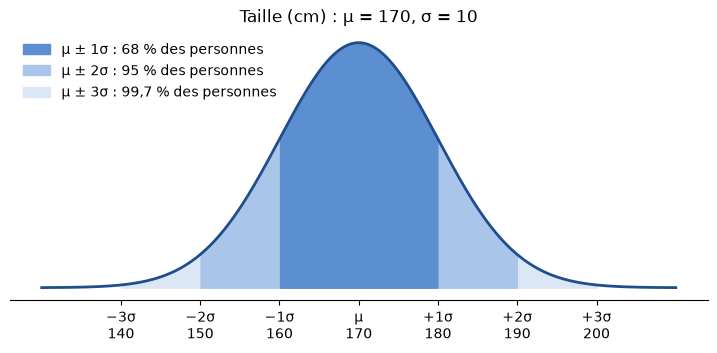

In [24]:
x = np.linspace(130, 210, 400)
courbe = np.exp(-((x - 170) / 10) ** 2 / 2)

fig, ax = plt.subplots(figsize=(9, 3.5))
for k, teinte, part in [(1, "#5b8fd1", "68 %"), (2, "#a9c6ea", "95 %"), (3, "#dbe7f5", "99,7 %")]:
    zone = (x >= 170 - 10 * k) & (x <= 170 + 10 * k)
    ax.fill_between(x[zone], courbe[zone], color=teinte, zorder=4 - k,
                    label=f"μ ± {k}σ : {part} des personnes")
ax.plot(x, courbe, color="#1f4e8c", linewidth=2, zorder=4)
ax.set_xticks(range(140, 201, 10))
ax.set_xticklabels(["−3σ\n140", "−2σ\n150", "−1σ\n160", "μ\n170", "+1σ\n180", "+2σ\n190", "+3σ\n200"])
ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_title("Taille (cm) : μ = 170, σ = 10")
ax.legend(loc="upper left", frameon=False)
plt.show()

Vérifions ces pourcentages. On tire au hasard 100 000 tailles qui suivent cette courbe, puis on
compte combien tombent dans chaque zone.

In [25]:
tirage = np.random.default_rng(0)
tailles = pd.Series(tirage.normal(170, 10, 100_000))

for k in [1, 2, 3]:
    dedans = tailles.between(170 - 10 * k, 170 + 10 * k).mean()
    print(f"entre {170 - 10 * k} et {170 + 10 * k} cm : {dedans:.1%}")

print(f"au-delà de 3σ (moins de 140 ou plus de 200 cm) : {1 - tailles.between(140, 200).mean():.2%}")

entre 160 et 180 cm : 68.4%
entre 150 et 190 cm : 95.5%
entre 140 et 200 cm : 99.7%
au-delà de 3σ (moins de 140 ou plus de 200 cm) : 0.29%


68 %, 95 %, 99,7 % : la règle du TD. Au-delà de 3σ, il reste environ 0,3 % des valeurs, 3 sur
1 000. D'où le seuil : |z| > 3 veut dire « très rare, **si les données ont la forme d'une
cloche** ».

Les salaires de `Data.csv` ont-ils cette forme ? L'histogramme range les salaires par tranches
et compte combien il y en a dans chaque tranche :

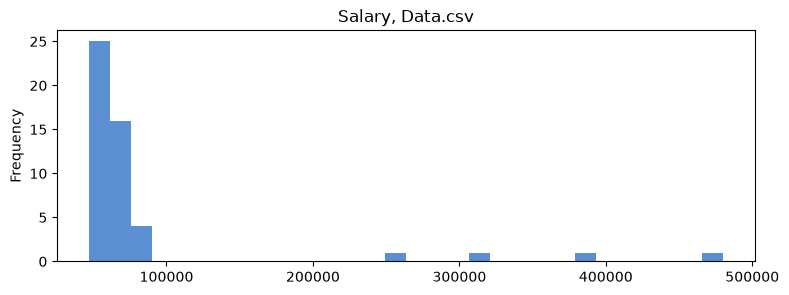

In [26]:
data["Salary"].plot(kind="hist", bins=30, figsize=(9, 3), color="#5b8fd1", title="Salary, Data.csv");

Non : un gros paquet autour de 60 000, et quatre points isolés très loin à droite. Pas de
cloche ici. Il faut une méthode qui ne suppose aucune forme : les quartiles.

### 4.3 Les quartiles

Les quartiles coupent les données **triées** en quatre parts égales :

| Quartile | Ce qu'il dit |
|---|---|
| Q1 | 25 % des valeurs sont en dessous |
| Q2 | 50 % sont en dessous : c'est la **médiane** |
| Q3 | 75 % sont en dessous |

Le TD prend 12 salaires, en k€. **Étape 1 : trier.**

In [27]:
s12 = pd.Series([48, 52, 54, 58, 61, 67, 72, 79, 83, 250, 320, 480]).sort_values()
n = len(s12)
s12.tolist()

[48, 52, 54, 58, 61, 67, 72, 79, 83, 250, 320, 480]

**Étape 2 : les positions**, (n + 1) × p :

In [28]:
for nom, p in [("Q1", 0.25), ("Q2", 0.50), ("Q3", 0.75)]:
    print(nom, ": position", (n + 1) * p)

Q1 : position 3.25
Q2 : position 6.5
Q3 : position 9.75


**Étape 3 : la valeur à cette position.** Position 3,25 : on part de la 3e valeur, et on avance
d'un quart du chemin vers la 4e. La fonction ci-dessous fait exactement le calcul du TD.

In [29]:
def quartile_du_td(valeurs, p):
    triees = sorted(valeurs)
    position = (len(triees) + 1) * p      # par exemple 3.25
    rang = int(position)                  # 3
    fraction = position - rang            # 0.25
    avant = triees[rang - 1]              # la 3e valeur (Python compte à partir de 0)
    apres = triees[rang]                  # la 4e valeur
    return avant + fraction * (apres - avant)


q1 = quartile_du_td(s12, 0.25)
q2 = quartile_du_td(s12, 0.50)
q3 = quartile_du_td(s12, 0.75)
print("Q1 =", q1, "  Q2 =", q2, "  Q3 =", q3)

Q1 = 55.0   Q2 = 69.5   Q3 = 208.25


Q1 = 55, Q2 = 69,5, Q3 = 208,25 : les valeurs du TD.

**À savoir : il existe plusieurs façons de calculer un quartile.** Sur un grand fichier, elles
donnent presque la même chose ; sur 12 valeurs, pas toujours. Celle du TD s'appelle
`"weibull"` dans numpy. pandas, par défaut, en utilise une autre :

In [30]:
pd.DataFrame({
    "méthode du TD": np.percentile(s12, [25, 50, 75], method="weibull"),
    "pandas, par défaut": s12.quantile([0.25, 0.50, 0.75]).values,
}, index=["Q1", "Q2", "Q3"])

,méthode du TD,"pandas, par défaut"
Q1,55.00,57.00
Q2,69.50,69.50
Q3,208.25,124.75


Q3 vaut 208,25 ou 124,75 selon la méthode : entre 83 et 250, il y a un tel saut que l'endroit
exact où l'on coupe change tout. Retenez l'idée, couper en quatre, plutôt qu'une formule.

### 4.4 Les valeurs extrêmes déplacent Q3

In [31]:
sans_extremes = [48, 52, 54, 58, 61, 67, 72, 79, 83]
q1_s, q2_s, q3_s = (quartile_du_td(sans_extremes, p) for p in (0.25, 0.50, 0.75))

print("Sans les extrêmes : Q1 =", q1_s, " Q2 =", q2_s, " Q3 =", q3_s, " IQR =", q3_s - q1_s)
print("Avec              : Q1 =", q1, " Q2 =", q2, " Q3 =", q3, " IQR =", q3 - q1)

Sans les extrêmes : Q1 = 53.0  Q2 = 61.0  Q3 = 75.5  IQR = 22.5
Avec              : Q1 = 55.0  Q2 = 69.5  Q3 = 208.25  IQR = 153.25


Sans les extrêmes, l'écart Q3 − Q1 vaut 22,5 k€ (le TD donne des quartiles lus à vue, ≈ 54 et
≈ 79, d'où ≈ 25). Avec eux, 153,25 k€ : près de sept fois plus. Ici, 3 salaires sur 12 sont
extrêmes, un quart des données : même les quartiles finissent par bouger. Quand une valeur est
manifestement impossible, on peut la retirer d'abord, puis chercher les cas plus subtils.

### 4.5 L'écart interquartile et la règle 1,5 × IQR

L'**écart interquartile**, IQR = Q3 − Q1, contient la moitié centrale des données. La règle de
Tukey fixe deux bornes : Q1 − 1,5 × IQR et Q3 + 1,5 × IQR. Au-delà, la valeur est signalée.

In [32]:
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr

print("IQR         =", iqr)
print("Borne basse =", borne_basse, "  (un salaire n'est jamais négatif : en pratique, 0)")
print("Borne haute =", borne_haute)

s12[(s12 < borne_basse) | (s12 > borne_haute)]

IQR         = 153.25
Borne basse = -174.875   (un salaire n'est jamais négatif : en pratique, 0)
Borne haute = 438.125


11    480
dtype: int64

Seul 480 k€ dépasse 438,1 k€ : c'est un outlier. 250 et 320 restent dans les bornes, comme dans
le TD.

Pourquoi 1,5 ? Sur une courbe de Gauss, ces bornes tombent à environ 2,7σ de la moyenne : 99,3 %
des valeurs sont à l'intérieur. La règle signale donc peu de valeurs normales, mais sans
supposer de cloche.

### 4.6 Z-score ou IQR ?

| | Z-score | IQR (Tukey) |
|---|---|---|
| Basé sur | la moyenne et l'écart-type | les quartiles |
| Sensible aux valeurs extrêmes ? | oui | beaucoup moins (mais pas immunisé, voir 4.4) |
| Forme des données | en cloche | n'importe laquelle |
| Seuil | \|z\| > 3 | hors de [Q1 − 1,5 × IQR ; Q3 + 1,5 × IQR] |

Le conseil du TD : l'IQR quand la forme est inconnue ou asymétrique, comme les salaires.
Comparons les deux sur les 49 salaires du fichier :

In [33]:
sal = data["Salary"]

z_fichier = (sal - sal.mean()) / sal.std(ddof=0)
print("z-score, |z| > 3 :", sorted(sal[z_fichier.abs() > 3].tolist()))

q1_f, q3_f = sal.quantile(0.25), sal.quantile(0.75)
haute_f = q3_f + 1.5 * (q3_f - q1_f)
print("Tukey, au-dessus de", haute_f, ":", sorted(sal[sal > haute_f].tolist()))

z-score, |z| > 3 : [390000.0, 480000.0]
Tukey, au-dessus de 88500.0 : [250000.0, 320000.0, 390000.0, 480000.0]


Le z-score en voit 2, la règle de Tukey 4. Les quatre salaires extrêmes gonflent l'écart-type
(près de 86 000), ce qui rend le z-score indulgent : 250 000 n'obtient qu'un z de 1,9.

La **boîte à moustaches** dessine la règle de Tukey : la boîte va de Q1 à Q3, le trait au milieu
est la médiane, les moustaches s'arrêtent aux dernières valeurs dans les bornes, et chaque point
isolé est une valeur signalée.

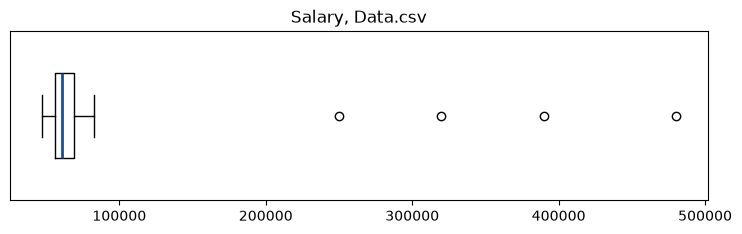

In [34]:
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.boxplot(data["Salary"].dropna(), orientation="horizontal", widths=0.5,
           medianprops={"color": "#1f4e8c", "linewidth": 2})
ax.set_yticks([])
ax.set_title("Salary, Data.csv")
plt.show()

### 4.7 Exercice 3 : 10, 12, 14, 15, 16, 18, 20, 45

Y a-t-il un outlier ? On applique la règle de Tukey avec trois façons de calculer les quartiles :

In [35]:
valeurs = [10, 12, 14, 15, 16, 18, 20, 45]

lignes = []
for methode in ["weibull", "midpoint", "linear"]:
    q1_e, q3_e = np.percentile(valeurs, [25, 75], method=methode)
    haute = q3_e + 1.5 * (q3_e - q1_e)
    lignes.append([methode, q1_e, q3_e, q3_e - q1_e, haute, bool(45 > haute)])

pd.DataFrame(lignes, columns=["méthode", "Q1", "Q3", "IQR", "borne haute", "45 est signalé ?"])

,méthode,Q1,Q3,IQR,borne haute,45 est signalé ?
0,weibull,12.5,19.5,7.0,30.0,True
1,midpoint,13.0,19.0,6.0,28.0,True
2,linear,13.5,18.5,5.0,26.0,True


La solution du TD (Q1 = 13, Q3 = 19, borne 28) prend le milieu entre deux valeurs voisines :
c'est la ligne `midpoint`. Les trois méthodes ne donnent pas les mêmes bornes, mais toutes
donnent la même réponse : **45 est un outlier**.

## 5. Problème 3 : les variables catégorielles

Un modèle ne calcule qu'avec des nombres. Il faut donc transformer le texte, et la bonne façon
dépend du type de colonne.

### Nominale, sans ordre : le one-hot (`Country`)

Une colonne par pays, avec 1 ou 0. Chaque ligne a un seul 1.

In [36]:
pays = pd.DataFrame({"Country": ["France", "Spain", "Germany"]})
pd.get_dummies(pays, columns=["Country"], dtype=int)

,Country_France,Country_Germany,Country_Spain
0,1,0,0
1,0,0,1
2,0,1,0


Pourquoi pas simplement France = 0, Spain = 1, Germany = 2 ? Le modèle croirait que Germany
« vaut » deux fois Spain, et que Spain se trouve « entre » France et Germany. Ces nombres
inventeraient un ordre qui n'existe pas.

### Ordinale, avec un ordre : un code qui le respecte (`Education`)

HighSchool < Bachelor < Master < PhD. Des nombres qui suivent cet ordre disent la vérité.

In [37]:
ordre_education = {"HighSchool": 0, "Bachelor": 1, "Master": 2, "PhD": 3}

exemple = data[["Education"]].head(6).copy()
exemple["Education_code"] = exemple["Education"].map(ordre_education)
exemple

,Education,Education_code
0,Master,2
1,Bachelor,1
2,Bachelor,1
3,Master,2
4,PhD,3
5,Bachelor,1


### Attention : `LabelEncoder` ne connaît pas votre ordre

Le code du TD utilise `LabelEncoder`, de scikit-learn. Il range les catégories par **ordre
alphabétique**, quel que soit l'ordre dans lequel on les lui donne :

In [38]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(["HighSchool", "Bachelor", "Master", "PhD"])
pd.Series(le.transform(le.classes_), index=le.classes_)

Bachelor      0
HighSchool    1
Master        2
PhD           3
dtype: int64

Bachelor = 0, HighSchool = 1 : le lycée passe après la licence, l'ordre est cassé.
`LabelEncoder` est fait pour la **cible** (No, Yes). Pour une colonne ordinale, donnez l'ordre
vous-même : avec un dictionnaire, comme ci-dessus, ou avec `OrdinalEncoder` :

In [39]:
from sklearn.preprocessing import OrdinalEncoder

encodeur = OrdinalEncoder(categories=[["HighSchool", "Bachelor", "Master", "PhD"]])
diplomes = pd.DataFrame({"Education": ["PhD", "HighSchool", "Master", "Bachelor"]})
diplomes["code"] = encodeur.fit_transform(diplomes[["Education"]])
diplomes

,Education,code
0,PhD,3.0
1,HighSchool,0.0
2,Master,2.0
3,Bachelor,1.0


### Exercice 4 : encoder `Color` et `Size`

In [40]:
exo = pd.DataFrame({
    "ID": [1, 2, 3],
    "Color": ["Red", "Blue", "Red"],
    "Size": ["Small", "Large", "Medium"],
})
exo

,ID,Color,Size
0,1,Red,Small
1,2,Blue,Large
2,3,Red,Medium


In [41]:
resultat = pd.get_dummies(exo, columns=["Color"], dtype=int)
resultat["Size_Code"] = resultat["Size"].map({"Small": 0, "Medium": 1, "Large": 2})
resultat.drop(columns="Size")

,ID,Color_Blue,Color_Red,Size_Code
0,1,0,1,0
1,2,1,0,2
2,3,0,1,1


La solution du TD : `Color` en one-hot, car les couleurs n'ont pas d'ordre ; `Size` en code
ordinal, car Small < Medium < Large. pandas range les colonnes one-hot par ordre alphabétique :
Blue avant Red.

## 6. Problème 4 : la corrélation

Le coefficient de corrélation r va de −1 à 1. Proche de 1 : les deux colonnes montent
ensemble. Proche de −1 : quand l'une monte, l'autre descend. Proche de 0 : pas de lien en ligne
droite.

### Le calcul du TD

In [42]:
ae = pd.DataFrame({"Age": [25, 30, 35, 40], "Experience": [3, 8, 13, 18]})
ae

,Age,Experience
0,25,3
1,30,8
2,35,13
3,40,18


**Étape 1 : les moyennes.**

In [43]:
x_moy = ae["Age"].mean()
y_moy = ae["Experience"].mean()
print("x̄ =", x_moy, "   ȳ =", y_moy)

x̄ = 32.5    ȳ = 10.5


**Étape 2 : les écarts à la moyenne, leurs produits, leurs carrés.**

In [44]:
calcul = pd.DataFrame({
    "xi": ae["Age"],
    "yi": ae["Experience"],
    "xi − x̄": ae["Age"] - x_moy,
    "yi − ȳ": ae["Experience"] - y_moy,
})
calcul["(xi − x̄)(yi − ȳ)"] = calcul["xi − x̄"] * calcul["yi − ȳ"]
calcul["(xi − x̄)²"] = calcul["xi − x̄"] ** 2
calcul["(yi − ȳ)²"] = calcul["yi − ȳ"] ** 2
calcul

,xi,yi,xi − x̄,yi − ȳ,(xi − x̄)(yi − ȳ),(xi − x̄)²,(yi − ȳ)²
0,25,3,-7.5,-7.5,56.25,56.25,56.25
1,30,8,-2.5,-2.5,6.25,6.25,6.25
2,35,13,2.5,2.5,6.25,6.25,6.25
3,40,18,7.5,7.5,56.25,56.25,56.25


In [45]:
sommes = calcul[["(xi − x̄)(yi − ȳ)", "(xi − x̄)²", "(yi − ȳ)²"]].sum()
sommes

(xi − x̄)(yi − ȳ)    125.0
(xi − x̄)²           125.0
(yi − ȳ)²            125.0
dtype: float64

**Étape 3 : la formule** r = Σ(xi − x̄)(yi − ȳ) ÷ √[Σ(xi − x̄)² × Σ(yi − ȳ)²].

In [46]:
r = sommes.iloc[0] / (sommes.iloc[1] * sommes.iloc[2]) ** 0.5
print("r =", r)

r = 1.0


r = 1 : corrélation parfaite. Ici Experience = Age − 22, exactement. Connaître l'une, c'est
connaître l'autre. pandas fait tout cela en une ligne :

In [47]:
ae.corr()

,Age,Experience
Age,1.0,1.0
Experience,1.0,1.0


### Sur le fichier : `Age` et `Experience`

Un nuage de points : chaque point est un client, placé selon son âge et son expérience.

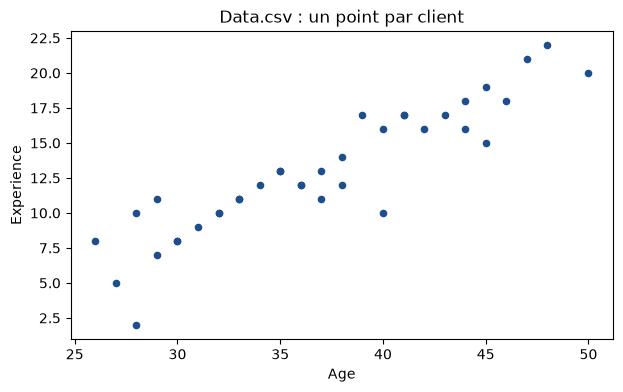

In [48]:
data.plot(kind="scatter", x="Age", y="Experience", figsize=(7, 4), color="#1f4e8c",
          title="Data.csv : un point par client");

In [49]:
print("r =", round(data["Age"].corr(data["Experience"]), 3))

r = 0.913


r = 0,913 : pas 1, mais très fort. Les deux colonnes racontent presque la même histoire. On n'en
garde qu'une : le modèle est plus simple, et il n'a pas à se partager entre deux colonnes
jumelles. Le TD supprime `Experience`.

> **À noter.** On aurait pu, à l'inverse, garder `Experience` et supprimer `Age` :
> `Experience` n'a aucune case vide, `Age` en a 13. Les deux choix se défendent ; ce qui compte,
> c'est de savoir justifier le sien.

Le TD cite une autre solution, l'ACP (*PCA* en anglais), qui remplace des colonnes corrélées par
de nouvelles colonnes qui les résument. Elle sort du cadre de ce TD.

## 7. Problème 5 : mettre les colonnes à la même échelle

L'âge va de 26 à 50, le salaire de 47 000 à 480 000. Pour un modèle qui compare des clients en
mesurant des distances, un an d'écart pèse autant qu'un euro d'écart : le salaire écrase tout.
On ramène donc chaque colonne à une échelle comparable.

### Standardisation (z-score) : Z = (X − μ) ÷ σ

L'exemple du TD : âge 44, avec μ = 38 et σ = 7.

In [50]:
round((44 - 38) / 7, 3)

0.857

44 ans devient 0,857 : un peu moins d'un écart-type au-dessus de la moyenne. Après
standardisation, une colonne a une moyenne de 0 et un écart-type de 1.

### Min-max : X_norm = (X − min) ÷ (max − min)

27 et 50 sont le plus jeune et le plus âgé des 10 clients du TD.

In [51]:
round((44 - 27) / (50 - 27), 3)

0.739

44 ans devient 0,739. Après min-max, le plus petit vaut 0, le plus grand vaut 1.

### Exercice 5 : 10, 15, 20, 25, 30

À la main, puis avec `MinMaxScaler` de scikit-learn :

In [52]:
from sklearn.preprocessing import MinMaxScaler

exo5 = pd.DataFrame({"Original": [10, 15, 20, 25, 30]})
exo5["à la main"] = (exo5["Original"] - 10) / (30 - 10)
exo5["scikit-learn"] = MinMaxScaler().fit_transform(exo5[["Original"]])
exo5

,Original,à la main,scikit-learn
0,10,0.00,0.00
1,15,0.25,0.25
2,20,0.50,0.50
3,25,0.75,0.75
4,30,1.00,1.00


Mêmes résultats : 0 ; 0,25 ; 0,5 ; 0,75 ; 1.

Laquelle choisir ? Le min-max donne des bornes nettes (0 et 1), mais un seul salaire à 480 000
suffit à écraser tous les autres près de 0. La standardisation n'a pas de bornes et résiste un
peu mieux. Dans tous les cas, on traite les valeurs extrêmes **avant** de mettre à l'échelle.

## 8. L'ordre des étapes, et le piège du data leakage

Le TD fixe un ordre :

1. analyser les données ;
2. identifier les problèmes ;
3. encoder les catégories (avant la division) ;
4. éliminer les colonnes jumelles (avant la division) ;
5. **diviser en train et test** ;
6. imputer : `fit` sur le train, `transform` sur le test ;
7. détecter et traiter les valeurs extrêmes, avec des bornes calculées sur le train ;
8. normaliser : `fit` sur le train, `transform` sur le test.

**Train et test.** On met de côté 20 % des clients, le *test*. Le modèle apprendra sur les 80 %
restants, le *train*, puis on le jugera sur les clients du test, qu'il n'aura jamais vus. C'est
la seule façon honnête de savoir s'il marchera sur de nouveaux clients.

**Le data leakage**, ou fuite de données : utiliser une information du test pendant la
préparation du train. Exemple : calculer la moyenne des salaires sur tout le fichier, puis
s'en servir pour remplir les cases vides. Regardons ce que cela change :

In [53]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, random_state=42)
print("Train :", len(train), "clients   Test :", len(test), "clients")
print()
print("Salaire moyen, fichier entier :", round(data["Salary"].mean()))
print("Salaire moyen, train seul     :", round(train["Salary"].mean()))

Train : 40 clients   Test : 10 clients

Salaire moyen, fichier entier : 85959
Salaire moyen, train seul     : 76641


Les deux moyennes diffèrent : le test contient deux des salaires extrêmes. Si on prépare le
train avec la moyenne du fichier entier, le train contient déjà un peu du test. Le modèle sera
ensuite jugé sur des clients dont il a, en partie, vu les chiffres : un résultat trop beau, et
faux.

**Règle d'or : `fit()` sur le train, `transform()` sur le test.** `fit` apprend les paramètres
(moyenne, médiane, bornes, min et max) ; `transform` les applique.

## 9. Du papier au code : le prétraitement complet

On repart du fichier brut et on applique tout, dans l'ordre du TD.

### 9.1 Charger, séparer les features et la cible

`X` contient ce qu'on sait du client, les *features*. `y` contient ce qu'on veut prédire, la
cible, encodée No → 0 et Yes → 1.

In [54]:
data = pd.read_csv("donnees/Data.csv")

X = data.drop(columns="Purchased")
y = data["Purchased"].map({"No": 0, "Yes": 1})

X.head()

,Country,Age,Salary,Education,Experience
0,France,44.0,72000.0,Master,16
1,Spain,27.0,48000.0,Bachelor,5
2,Germany,30.0,54000.0,Bachelor,8
3,Spain,38.0,61000.0,Master,12
4,Germany,40.0,NaN,PhD,10


### 9.2 Encoder les catégories (avant la division)

In [55]:
X = pd.get_dummies(X, columns=["Country"], dtype=int)
X["Education"] = X["Education"].map(ordre_education)

X.head()

,Age,Salary,Education,Experience,Country_Canada,Country_France,Country_Germany,Country_Spain,Country_UK,Country_USA
0,44.0,72000.0,2,16,0,1,0,0,0,0
1,27.0,48000.0,1,5,0,0,0,1,0,0
2,30.0,54000.0,1,8,0,0,1,0,0,0
3,38.0,61000.0,2,12,0,0,0,1,0,0
4,40.0,NaN,3,10,0,0,1,0,0,0


`Country` est devenue six colonnes de 0 et de 1, `Education` un code de 0 à 3. Ces deux gestes
ne calculent rien à partir des clients (ni moyenne, ni borne) : on peut les faire avant la
division sans fuite.

### 9.3 Supprimer la colonne jumelle (avant la division)

In [56]:
print("r(Age, Experience) =", round(X["Age"].corr(X["Experience"]), 3))

X = X.drop(columns="Experience")
list(X.columns)

r(Age, Experience) = 0.913


['Age',
 'Salary',
 'Education',
 'Country_Canada',
 'Country_France',
 'Country_Germany',
 'Country_Spain',
 'Country_UK',
 'Country_USA']

### 9.4 Diviser : 80 % pour le train, 20 % pour le test

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train :", X_train.shape, "   X_test :", X_test.shape)

X_train : (40, 9)    X_test : (10, 9)


40 clients pour apprendre, 10 pour juger. `random_state=42` rend le tirage identique à chaque
exécution, chez vous comme ici. **À partir de maintenant, tout ce qui se calcule se calcule sur
le train.**

### 9.5 Imputer : `fit` sur le train, `transform` sur les deux

In [58]:
from sklearn.impute import SimpleImputer

colonnes_num = ["Age", "Salary"]

imputer = SimpleImputer(strategy="median")
X_train[colonnes_num] = imputer.fit_transform(X_train[colonnes_num])
X_test[colonnes_num] = imputer.transform(X_test[colonnes_num])

print("Médianes apprises sur le train : Age =", imputer.statistics_[0], "  Salary =", imputer.statistics_[1])
print("Cases vides restantes :", X_train.isna().sum().sum(), "dans le train,", X_test.isna().sum().sum(), "dans le test")

Médianes apprises sur le train : Age = 37.0   Salary = 61000.0
Cases vides restantes : 0 dans le train, 0 dans le test


La médiane pour les deux colonnes. Le code du TD utilise la moyenne pour le salaire ; avec
quatre salaires extrêmes, la médiane est plus sûre (partie 3). Les cases vides du test sont
remplies avec les médianes **du train** : `transform`, jamais `fit`.

### 9.6 Les valeurs extrêmes : des bornes calculées sur le train

In [59]:
q1_train = X_train["Salary"].quantile(0.25)
q3_train = X_train["Salary"].quantile(0.75)
iqr_train = q3_train - q1_train
basse = q1_train - 1.5 * iqr_train
haute = q3_train + 1.5 * iqr_train

print("Bornes apprises sur le train :", basse, "et", haute)
print("Au-dessus, dans le train :", sorted(X_train.loc[X_train["Salary"] > haute, "Salary"].tolist()))
print("Au-dessus, dans le test  :", sorted(X_test.loc[X_test["Salary"] > haute, "Salary"].tolist()))

Bornes apprises sur le train : 41000.0 et 83000.0
Au-dessus, dans le train : [320000.0, 390000.0]
Au-dessus, dans le test  : [250000.0, 480000.0]


Les quatre salaires extrêmes sont repérés : deux dans le train, deux dans le test. On ne
supprime pas ces clients : on **plafonne** leur salaire à la borne haute (en anglais,
*capping*). `clip` fait exactement cela, avec les mêmes bornes pour le train et le test.

In [60]:
X_train["Salary"] = X_train["Salary"].clip(basse, haute)
X_test["Salary"] = X_test["Salary"].clip(basse, haute)

print("Plus haut salaire, train :", X_train["Salary"].max())
print("Plus haut salaire, test  :", X_test["Salary"].max())

Plus haut salaire, train : 83000.0
Plus haut salaire, test  : 83000.0


### 9.7 Standardiser : `fit` sur le train, `transform` sur les deux

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[colonnes_num] = scaler.fit_transform(X_train[colonnes_num])
X_test[colonnes_num] = scaler.transform(X_test[colonnes_num])

pd.DataFrame({
    "moyenne, train": X_train[colonnes_num].mean(),
    "écart-type, train": X_train[colonnes_num].std(ddof=0),
    "moyenne, test": X_test[colonnes_num].mean(),
    "écart-type, test": X_test[colonnes_num].std(ddof=0),
}).round(2) + 0.0   # « + 0.0 » évite l'affichage « -0.0 »

,"moyenne, train","écart-type, train","moyenne, test","écart-type, test"
Age,0.0,1.0,0.02,1.34
Salary,0.0,1.0,0.35,1.36


Train : moyenne 0, écart-type 1, par construction. Test : ni 0 ni 1, et assez loin pour le
salaire (10 clients seulement, dont deux plafonnés). Il a été transformé avec la moyenne et
l'écart-type **du train**, pas avec les siens. C'est normal, et c'est voulu : le test ne doit
rien influencer.

On standardise seulement l'âge et le salaire : les colonnes one-hot (0 ou 1) et le code du
diplôme (0 à 3) sont déjà sur de petites échelles.

### 9.8 Les données sont prêtes

In [62]:
print("X_train :", X_train.shape, "   X_test :", X_test.shape)
X_train.head().round(2)

X_train : (40, 9)    X_test : (10, 9)


,Age,Salary,Education,Country_Canada,Country_France,Country_Germany,Country_Spain,Country_UK,Country_USA
12,-1.54,-1.26,1,0,0,0,0,1,0
4,0.58,-0.18,3,0,0,1,0,0,0
37,0.58,0.47,2,1,0,0,0,0,0
8,2.51,2.20,3,0,0,1,0,0,0
3,0.20,-0.18,2,0,0,0,1,0,0


Plus de texte, plus de case vide, plus de salaire extrême, des échelles comparables, et un test
qui n'a rien appris au train. Un modèle peut maintenant apprendre sur `X_train` et `y_train`.

### 9.9 Le même travail en un seul objet : le `Pipeline`

scikit-learn sait enchaîner ces étapes. Un `ColumnTransformer` applique à chaque colonne son
traitement ; un `Pipeline` met des étapes bout à bout. Un seul `fit` sur le train, un seul
`transform` sur le test : impossible d'oublier une étape, ou de la faire dans le mauvais ordre.

In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X_brut = data.drop(columns=["Purchased", "Experience"])
y = data["Purchased"].map({"No": 0, "Yes": 1})
X_train_b, X_test_b, y_train, y_test = train_test_split(X_brut, y, test_size=0.2, random_state=42)

preparation = ColumnTransformer([
    ("nombres", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), ["Age", "Salary"]),
    ("pays", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), ["Country"]),
    ("diplome", OrdinalEncoder(categories=[["HighSchool", "Bachelor", "Master", "PhD"]]), ["Education"]),
])

X_train_p = preparation.fit_transform(X_train_b)   # fit + transform sur le train
X_test_p = preparation.transform(X_test_b)         # transform seulement sur le test

print("train :", X_train_p.shape, "   test :", X_test_p.shape)
pd.DataFrame(X_train_p, columns=preparation.get_feature_names_out()).head().round(2)

train : (40, 9)    test : (10, 9)


,nombres__Age,nombres__Salary,pays__Country_Canada,pays__Country_France,pays__Country_Germany,pays__Country_Spain,pays__Country_UK,pays__Country_USA,diplome__Education
0,-1.54,-0.39,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.58,-0.23,0.0,0.0,1.0,0.0,0.0,0.0,3.0
2,0.58,-0.14,1.0,0.0,0.0,0.0,0.0,0.0,2.0
3,2.51,0.10,0.0,0.0,1.0,0.0,0.0,0.0,3.0
4,0.20,-0.23,0.0,0.0,0.0,1.0,0.0,0.0,2.0


Mêmes colonnes, même règle. Une différence : comme celui du TD, ce pipeline ne plafonne pas
les salaires extrêmes. On pourrait lui ajouter cette étape, mais cela dépasse ce TD.

## 10. Formulaire

| | Formule |
|---|---|
| Moyenne | μ = Σx ÷ n |
| Médiane | la valeur du milieu, après tri |
| Écart-type | σ = √(Σ(x − μ)² ÷ n) |
| Z-score | Z = (x − μ) ÷ σ |
| Écart interquartile | IQR = Q3 − Q1 |
| Bornes de Tukey | Q1 − 1,5 × IQR et Q3 + 1,5 × IQR |
| Min-max | (x − min) ÷ (max − min) |
| Corrélation | r = Σ(x − x̄)(y − ȳ) ÷ √[Σ(x − x̄)² × Σ(y − ȳ)²], entre −1 et 1 |

## Ce qu'il faut retenir

- **Regarder avant de coder** : `head`, `info`, `isna`, `describe`, un histogramme.
- **Comprendre le calcul** derrière chaque fonction : ici, chaque résultat de Python a été
  vérifié à la main.
- **Justifier ses choix** : médiane ou moyenne, z-score ou IQR, quelle colonne jumelle garder.
- **L'ordre compte** : encoder, diviser, puis imputer, traiter les extrêmes, mettre à l'échelle.
- **`fit` sur le train, `transform` sur le test.**
- **Se méfier des outils qui décident à votre place** : `LabelEncoder` range par ordre
  alphabétique, et il existe plusieurs façons de calculer un quartile.